# Day 04：线性分类边界 —— 感知机的几何直觉

> ❄️ 第一周 · AI 的初春与寒冬 · 第 4 天

昨天我们用数字验证了感知机的计算过程。但数字是抽象的——今天我们把它**画出来**。

感知机的前向传播 `Z = X·W + b`，在二维空间中的几何含义就是：**画一条直线，把数据分成两半**。

**今天的任务**：
1. 可视化感知机的决策边界
2. 验证它能解决 AND、OR 等线性可分问题
3. 为明天的 XOR 危机做铺垫

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("绘图工具准备就绪！")

绘图工具准备就绪！


---

## 1. 决策边界：感知机在画什么？

感知机的公式是 `Z = X1*W1 + X2*W2 + b`。

当 `Z = 0` 时，我们得到一条直线的方程：

$$X_1 W_1 + X_2 W_2 + b = 0$$

解出 $X_2$：

$$X_2 = -\frac{W_1}{W_2} X_1 - \frac{b}{W_2}$$

这就是一条 $y = kx + m$ 的直线！

- **斜率** $k = -W_1/W_2$
- **截距** $m = -b/W_2$

这条线就是感知机的**「决策边界」**：线的一边输出 0，另一边输出 1。

In [2]:
# 本notebook独立定义Perceptron类，额外增加score方法用于可视化
class Perceptron:
    """完整的感知机"""
    def __init__(self, input_features_count=2):
        self.weights = torch.randn(input_features_count, 1)
        self.bias = torch.randn(1)
    
    def forward(self, inputs):
        z = torch.matmul(inputs, self.weights) + self.bias
        return (z > 0).float()
    
    def score(self, inputs):
        """返回未激活的原始得分（用于可视化）"""
        return torch.matmul(inputs, self.weights) + self.bias

print("Perceptron 类定义完成")

Perceptron 类定义完成


---

## 2. 可视化函数

我们写一个通用的绘图函数，用来展示：
- 数据点（绿色=1，红色=0）
- 决策边界（蓝色直线）
- 感知机能否正确分类

In [3]:
def visualize_decision_boundary(neuron, X, y, title="感知机决策边界"):
    """
    可视化感知机的决策边界
    :param neuron: 训练好的感知机
    :param X: 输入数据 [N, 2]
    :param y: 真实标签 [N, 1]
    :param title: 图表标题
    """
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    # 画数据点
    for i in range(len(X)):
        x1, x2 = X[i].tolist()
        label = int(y[i].item())
        color = '#2ecc71' if label == 1 else '#e74c3c'  # 绿=1，红=0
        marker = 'o' if label == 1 else 'x'
        ax.scatter(x1, x2, c=color, s=200, marker=marker, 
                   edgecolors='black' if marker == 'o' else None, linewidth=2, zorder=5)
        ax.annotate(f'({int(x1)},{int(x2)})\ny={label}', 
                    (x1, x2), textcoords="offset points", 
                    xytext=(10, 10), fontsize=9)
    
    # 画决策边界 (Z=0 的等高线)
    w1 = neuron.weights[0].item()
    w2 = neuron.weights[1].item()
    b = neuron.bias.item()
    
    x1_range = np.linspace(-0.5, 1.5, 100)
    if abs(w2) > 1e-6:  # 避免除以零
        x2_boundary = -(w1 * x1_range + b) / w2
        ax.plot(x1_range, x2_boundary, 'b-', linewidth=2, label=f'决策边界\n{w1:.1f}*x1 + {w2:.1f}*x2 + {b:.1f} = 0')
    else:
        # w2 近乎 0，决策边界是垂直线
        x1_boundary = -b / w1
        ax.axvline(x=x1_boundary, color='blue', linewidth=2, label=f'决策边界\nx1 = {x1_boundary:.2f}')
    
    # 填充颜色区域
    xx1, xx2 = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid_input = torch.tensor(np.stack([xx1.ravel(), xx2.ravel()], axis=1), dtype=torch.float32)
    predictions = neuron.forward(grid_input).numpy().reshape(xx1.shape)
    ax.contourf(xx1, xx2, predictions, alpha=0.15, levels=[-0.5, 0.5, 1.5], 
                colors=['#e74c3c', '#2ecc71'])
    
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_xlabel('X1', fontsize=12)
    ax.set_ylabel('X2', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='upper left', fontsize=9)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("可视化函数准备就绪！")

可视化函数准备就绪！


---

## 3. AND 问题：感知机的胜利

AND（与门）的逻辑：**两个输入都为 1 时才输出 1**

| X1 | X2 | AND |
|----|----|-----|
| 0  | 0  |  0  |
| 0  | 1  |  0  |
| 1  | 0  |  0  |
| 1  | 1  |  1  |

只有一种情况输出 1，其余都是 0。看看感知机能画出一条直线切开它们吗？

AND 门感知机:
  权重: [1.0, 1.0]
  偏置: -1.5

验证:
  AND(0, 0) = 0  (expect 0) OK
  AND(0, 1) = 0  (expect 0) OK
  AND(1, 0) = 0  (expect 0) OK
  AND(1, 1) = 1  (expect 1) OK


/var/folders/8j/y1d6rhz547zg9vsg7mw95nwc0000gn/T/ipykernel_74966/1525988667.py:17: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x1, x2, c=color, s=200, marker=marker,


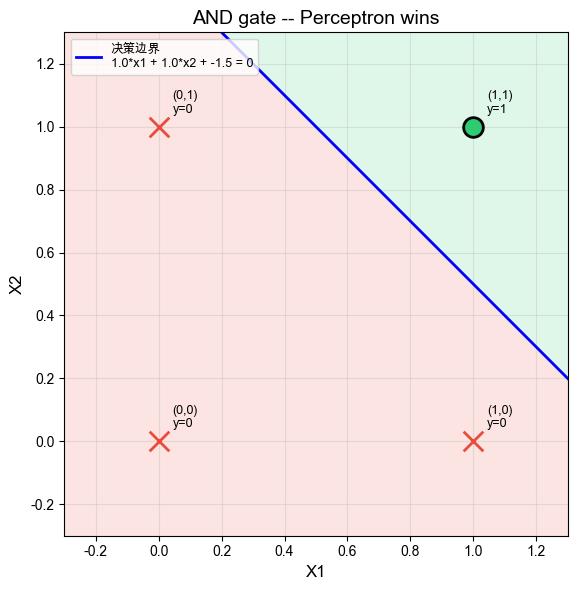

In [4]:
# AND 数据
X_and = torch.tensor([[0.0, 0.0],
                       [0.0, 1.0],
                       [1.0, 0.0],
                       [1.0, 1.0]])
y_and = torch.tensor([[0.0], [0.0], [0.0], [1.0]])

# 手动设定权重：只要两个输入都很强，才能越过门槛
and_neuron = Perceptron()
and_neuron.weights = torch.tensor([[1.0], [1.0]])
and_neuron.bias = torch.tensor([-1.5])  # 门槛设为 1.5

print("AND 门感知机:")
print(f"  权重: [{and_neuron.weights[0].item()}, {and_neuron.weights[1].item()}]")
print(f"  偏置: {and_neuron.bias.item()}")

# 验证
predictions = and_neuron.forward(X_and)
print(f"\n验证:")
for i in range(4):
    x = X_and[i].tolist()
    pred = int(predictions[i].item())
    true = int(y_and[i].item())
    match = "OK" if pred == true else "FAIL"
    print(f"  AND({int(x[0])}, {int(x[1])}) = {pred}  (expect {true}) {match}")

# 可视化
visualize_decision_boundary(and_neuron, X_and, y_and, "AND gate -- Perceptron wins")

### 解读

AND 问题中，只有右上角的 (1,1) 是绿色，其余三个红色点挤在左下角。

一条斜线就能轻松把它们分开——**这就是线性可分**。感知机在这种问题上毫无压力。

---

## 4. OR 问题：同样轻松

OR（或门）的逻辑：**只要有一个输入为 1 就输出 1**

| X1 | X2 | OR |
|----|----|----|
| 0  | 0  | 0  |
| 0  | 1  | 1  |
| 1  | 0  | 1  |
| 1  | 1  | 1  |

OR gate Perceptron:
  weights: [1.0, 1.0]
  bias: -0.5

Validation:
  OR(0, 0) = 0  (expect 0) OK
  OR(0, 1) = 1  (expect 1) OK
  OR(1, 0) = 1  (expect 1) OK
  OR(1, 1) = 1  (expect 1) OK


/var/folders/8j/y1d6rhz547zg9vsg7mw95nwc0000gn/T/ipykernel_74966/1525988667.py:17: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x1, x2, c=color, s=200, marker=marker,


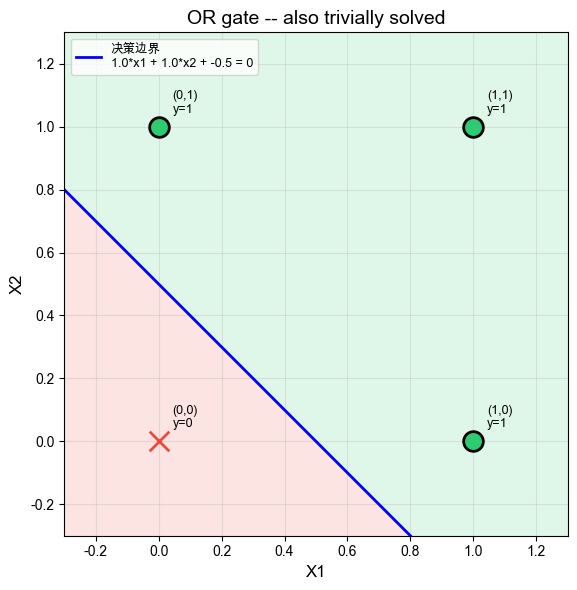

In [5]:
# OR 数据
X_or = torch.tensor([[0.0, 0.0],
                      [0.0, 1.0],
                      [1.0, 0.0],
                      [1.0, 1.0]])
y_or = torch.tensor([[0.0], [1.0], [1.0], [1.0]])

# 手动设定权重：只要有一个输入够强，就能越过门槛
or_neuron = Perceptron()
or_neuron.weights = torch.tensor([[1.0], [1.0]])
or_neuron.bias = torch.tensor([-0.5])  # 门槛很低

print("OR gate Perceptron:")
print(f"  weights: [{or_neuron.weights[0].item()}, {or_neuron.weights[1].item()}]")
print(f"  bias: {or_neuron.bias.item()}")

# 验证
predictions = or_neuron.forward(X_or)
print(f"\nValidation:")
for i in range(4):
    x = X_or[i].tolist()
    pred = int(predictions[i].item())
    true = int(y_or[i].item())
    match = "OK" if pred == true else "FAIL"
    print(f"  OR({int(x[0])}, {int(x[1])}) = {pred}  (expect {true}) {match}")

visualize_decision_boundary(or_neuron, X_or, y_or, "OR gate -- also trivially solved")

### 解读

OR 问题中，只有左下角的 (0,0) 是红色，其余三个绿点分布在其他位置。

同样一条直线就能分开——**线性可分**。

---

## 5. 对比：AND vs OR 的决策边界

两个问题的解法有什么共同点？让我们把它们放在一起看。

/var/folders/8j/y1d6rhz547zg9vsg7mw95nwc0000gn/T/ipykernel_74966/3997205914.py:13: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x1, x2, c=color, s=200, marker=marker,


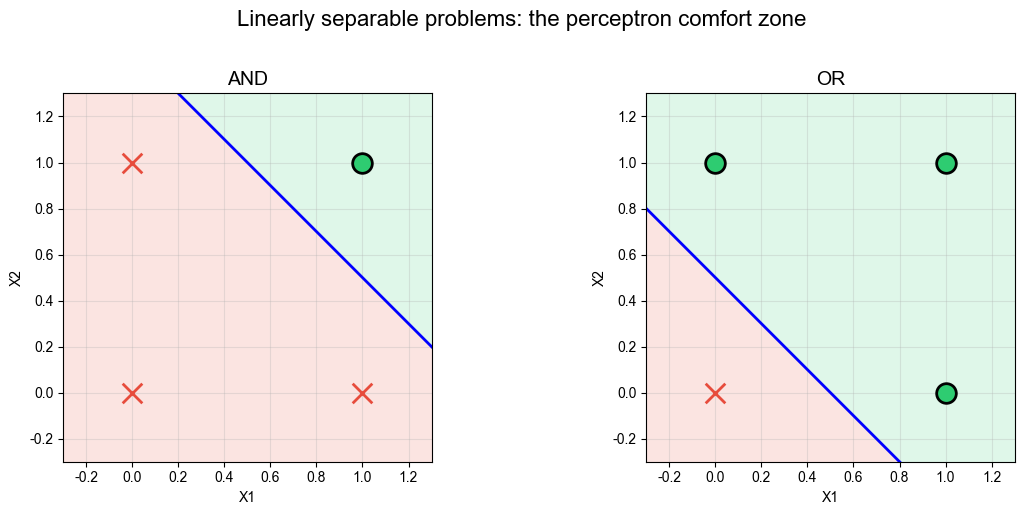

Common trait: both AND and OR can be split by a single straight line.
This is what 'linearly separable' means -- the perceptron's home turf.


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, (neuron, X, y, title) in [
    (ax1, (and_neuron, X_and, y_and, 'AND')),
    (ax2, (or_neuron, X_or, y_or, 'OR')),
]:
    # 数据点
    for i in range(len(X)):
        x1, x2 = X[i].tolist()
        label = int(y[i].item())
        color = '#2ecc71' if label == 1 else '#e74c3c'
        marker = 'o' if label == 1 else 'x'
        ax.scatter(x1, x2, c=color, s=200, marker=marker,
                   edgecolors='black' if marker == 'o' else None, linewidth=2, zorder=5)
    
    # 决策边界
    w1 = neuron.weights[0].item()
    w2 = neuron.weights[1].item()
    b = neuron.bias.item()
    x1_range = np.linspace(-0.5, 1.5, 100)
    x2_boundary = -(w1 * x1_range + b) / w2
    ax.plot(x1_range, x2_boundary, 'b-', linewidth=2)
    
    # 背景色
    xx1, xx2 = np.meshgrid(np.linspace(-0.3, 1.3, 200), np.linspace(-0.3, 1.3, 200))
    grid = torch.tensor(np.stack([xx1.ravel(), xx2.ravel()], axis=1), dtype=torch.float32)
    preds = neuron.forward(grid).numpy().reshape(xx1.shape)
    ax.contourf(xx1, xx2, preds, alpha=0.15, levels=[-0.5, 0.5, 1.5], colors=['#e74c3c', '#2ecc71'])
    
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Linearly separable problems: the perceptron comfort zone', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("Common trait: both AND and OR can be split by a single straight line.")
print("This is what 'linearly separable' means -- the perceptron's home turf.")

---

## 6. 预告：即将到来的风暴

AND 和 OR 太简单了——只需要一个绿点在一边，其余红色在另一边（或者反过来）。

但现实中，数据并不总是这么「乖巧」。想象一个更刁钻的问题——

**XOR（异或）：当两个输入不同时输出 1，相同时输出 0。**

```text
       X2
        |
    1   |   (0,1) [y=1] G        (1,1) [y=0] R
        |
    0   |   (0,0) [y=0] R        (1,0) [y=1] G
        |____________________________________ X1
            0                     1
```

Green 和 Red 呈对角交叉分布。

请你在脑海中试试：**能不能画一条直线，把所有 Green 和所有 Red 完美分开？**

**不可能！** 无论怎么画，都会有一边混入错误的颜色。

明天，我们将用代码和可视化，**亲眼见证这个导致 AI 第一次十年寒冬的历史性挫败。**

---

## 今日总结

| 概念 | 要点 |
|------|------|
| 决策边界 | Z=0 时的直线方程，斜率=-W1/W2，截距=-b/W2 |
| 线性可分 | 数据能被一条直线完美切开 |
| AND/OR | 线性可分 -> 感知机轻松解决 |
| XOR | 线性不可分 -> 感知机无能为力（明天验证） |

**明天预告**：XOR 危机——用代码和可视化证明感知机的致命缺陷，重现 AI 第一次寒冬的代码现场。